# Does a standard MMM over-credit paid search?

This notebook downloads a public dataset of real ecommerce brands, walks through one brand in three steps, then runs the same check on every eligible brand.

Run the cells from top to bottom. Each section ends with something to look at before you move on.

## 1. Setup

In [1]:
## Import  
import pathlib
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm

DATA_DIR = pathlib.Path("data")
plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})

## 2. Download the data

The dataset is on figshare: https://doi.org/10.6084/m9.figshare.25314841

This cell skips the download if a CSV is already in `data/`. If it fails, download the files by hand from that page and put them in `data/`.

In [2]:
## read the dataset from figshare ; you can also choose to download the data directly from this repo
DATA_DIR.mkdir(exist_ok=True)

files = requests.get("https://api.figshare.com/v2/articles/25314841").json()["files"]
for f in files:
    (DATA_DIR / f["name"]).write_bytes(requests.get(f["download_url"]).content)

print("Downloaded:", [f["name"] for f in files])

Downloaded: ['conjura_mmm_data_dictionary.xlsx', 'conjura_mmm_data.csv']


In [3]:
## Load
csv_files = list(DATA_DIR.glob("*.csv*"))
assert csv_files, "No CSV in data/. Run the download cell first (unzip the file if it came as a zip)."

data_file = max(csv_files, key=lambda p: p.stat().st_size)   # the largest CSV is the dataset or directly read with the file name
raw = pd.read_csv(data_file, low_memory=False)
raw["date"] = pd.to_datetime(raw["DATE_DAY"], dayfirst=True)

/tmp/ipykernel_1652/3333150653.py:7: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  raw["date"] = pd.to_datetime(raw["DATE_DAY"], dayfirst=True)


## 3. Load and take a first look

The file has one row per brand, territory and day.

In [4]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 132759 entries, 0 to 132758
Data columns (total 51 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   MMM_TIMESERIES_ID                    132759 non-null  str           
 1   ORGANISATION_ID                      132759 non-null  str           
 2   ORGANISATION_VERTICAL                124649 non-null  str           
 3   ORGANISATION_SUBVERTICAL             124649 non-null  str           
 4   ORGANISATION_MARKETING_SOURCES       132759 non-null  str           
 5   ORGANISATION_PRIMARY_TERRITORY_NAME  132759 non-null  str           
 6   TERRITORY_NAME                       132759 non-null  str           
 7   DATE_DAY                             132759 non-null  str           
 8   CURRENCY_CODE                        132759 non-null  str           
 9   FIRST_PURCHASES                      132759 non-null  int64         
 10  FIRST_P

In [5]:
# What kinds of brands are in here?
raw.groupby("ORGANISATION_VERTICAL")["ORGANISATION_ID"].nunique().sort_values(ascending=False)

ORGANISATION_VERTICAL
Apparel                  19
Home & Garden            16
Beauty & Fitness         13
Food & Drink              8
Health                    6
Sports                    5
Business & Industrial     4
Pets & Animals            2
Other                     2
Consumer Electronics      2
Autos & Vehicles          1
Arts & Entertainment      1
Safety & Survival         1
Toys & Hobbies            1
Travel                    1
Name: ORGANISATION_ID, dtype: int64

## 4. Build weekly data for one brand

The walk-through brand is a UK home and garden retailer. this is one of brands with the longest history in the dataset

| Name in the model | Built from | What it measures |
| --- | --- | --- |
| `revenue` | Purchases at original price, minus discounts | Weekly revenue |
| `social` | Meta impressions, adstocked | Paid social exposure |
| `search` | Google paid search clicks | Paid search activity |
| `demand` | Organic search clicks | Stand-in for search demand |
| controls | Other paid spend, a trend, time of year | Everything else |

In [6]:
raw.columns

Index(['MMM_TIMESERIES_ID', 'ORGANISATION_ID', 'ORGANISATION_VERTICAL',
       'ORGANISATION_SUBVERTICAL', 'ORGANISATION_MARKETING_SOURCES',
       'ORGANISATION_PRIMARY_TERRITORY_NAME', 'TERRITORY_NAME', 'DATE_DAY',
       'CURRENCY_CODE', 'FIRST_PURCHASES', 'FIRST_PURCHASES_UNITS',
       'FIRST_PURCHASES_ORIGINAL_PRICE', 'FIRST_PURCHASES_GROSS_DISCOUNT',
       'ALL_PURCHASES', 'ALL_PURCHASES_UNITS', 'ALL_PURCHASES_ORIGINAL_PRICE',
       'ALL_PURCHASES_GROSS_DISCOUNT', 'GOOGLE_PAID_SEARCH_SPEND',
       'GOOGLE_SHOPPING_SPEND', 'GOOGLE_PMAX_SPEND', 'GOOGLE_DISPLAY_SPEND',
       'GOOGLE_VIDEO_SPEND', 'META_FACEBOOK_SPEND', 'META_INSTAGRAM_SPEND',
       'META_OTHER_SPEND', 'TIKTOK_SPEND', 'GOOGLE_PAID_SEARCH_CLICKS',
       'GOOGLE_SHOPPING_CLICKS', 'GOOGLE_PMAX_CLICKS', 'GOOGLE_DISPLAY_CLICKS',
       'GOOGLE_VIDEO_CLICKS', 'META_FACEBOOK_CLICKS', 'META_INSTAGRAM_CLICKS',
       'META_OTHER_CLICKS', 'TIKTOK_CLICKS', 'GOOGLE_PAID_SEARCH_IMPRESSIONS',
       'GOOGLE_SHOPPING_IMPRESS

In [10]:
BRAND = "7059e30b528ed5f14ee9921de13248e5" ## id used in conjura

META_IMPRESSIONS = ["META_FACEBOOK_IMPRESSIONS", "META_INSTAGRAM_IMPRESSIONS", "META_OTHER_IMPRESSIONS"]
META_SPEND = ["META_FACEBOOK_SPEND", "META_INSTAGRAM_SPEND", "META_OTHER_SPEND"]
OTHER_SPEND = ["GOOGLE_SHOPPING_SPEND", "GOOGLE_PMAX_SPEND", "GOOGLE_DISPLAY_SPEND",
               "GOOGLE_VIDEO_SPEND", "TIKTOK_SPEND"]
CONTROLS = ["other_paid", "trend", "sin", "cos"] ## will be used to craete seasonal variables/ other controls artifically


#3 for ease of understanding : geometric decay is applied here
## For this particular example, lags and stauration are not used; in an ideal full funnel MMM lags and saturation are important transformations to perform 
def adstock(x, decay=0.5):
    """Carry part of each week's effect into later weeks."""
    out = np.zeros(len(x))
    for t in range(len(x)):
        out[t] = (1 - decay) * x[t] + (decay * out[t - 1] if t > 0 else 0)
    return out


## change data to weekly; create controls 
def weekly(brand, decay=0.5):
    """One row per week for one brand, with the columns the models need."""
    d = raw[(raw["ORGANISATION_ID"] == brand) & (raw["TERRITORY_NAME"] == "All Territories")]
    d = d.set_index("date").select_dtypes("number").fillna(0)
    d = d.resample("W-MON", label="left", closed="left").sum().iloc[1:-1]   # drop partial weeks
    w = pd.DataFrame(index=d.index)
    w["revenue"] = d["ALL_PURCHASES_ORIGINAL_PRICE"] - d["ALL_PURCHASES_GROSS_DISCOUNT"]
    w["social"] = adstock(d[META_IMPRESSIONS].sum(axis=1).to_numpy() / 1000, decay)
    w["social_cost"] = d[META_SPEND].sum(axis=1)
    w["search"] = d["GOOGLE_PAID_SEARCH_CLICKS"]
    w["search_cost"] = d["GOOGLE_PAID_SEARCH_SPEND"]
    w["demand"] = d["ORGANIC_SEARCH_CLICKS"]
    w["other_paid"] = d[OTHER_SPEND].sum(axis=1)
    week_of_year = w.index.isocalendar().week.to_numpy().astype(float)
    w["trend"] = np.arange(len(w))
    w["sin"] = np.sin(2 * np.pi * week_of_year / 52)
    w["cos"] = np.cos(2 * np.pi * week_of_year / 52)
    return w


w = weekly(BRAND)
print(f"{len(w)} weeks, {w.index.min().date()} to {w.index.max().date()}")
w.head()

234 weeks, 2019-11-25 to 2024-05-13


,revenue,social,social_cost,search,search_cost,demand,other_paid,trend,sin,cos
date,,,,,,,,,,
2019-11-25,19695.317379,18.651500,693.516517,964.0,684.51,1949.0,0.0,0,-4.647232e-01,0.885456
2019-12-02,9176.966754,13.261750,151.140000,716.0,485.58,1445.0,0.0,1,-3.546049e-01,0.935016
2019-12-09,10126.698283,13.468875,183.307657,601.0,489.11,1146.0,0.0,2,-2.393157e-01,0.970942
2019-12-16,7701.820000,16.630437,315.740000,516.0,343.30,1047.0,0.0,3,-1.205367e-01,0.992709
2019-12-23,4684.909275,8.315219,0.000000,858.0,578.04,1633.0,0.0,4,6.432491e-16,1.000000


In [8]:
# Totals over the whole period
w[["revenue", "social_cost", "search_cost", "other_paid"]].sum().round(0)

revenue        13093275.0
social_cost     1189712.0
search_cost      539243.0
other_paid       346822.0
dtype: float64

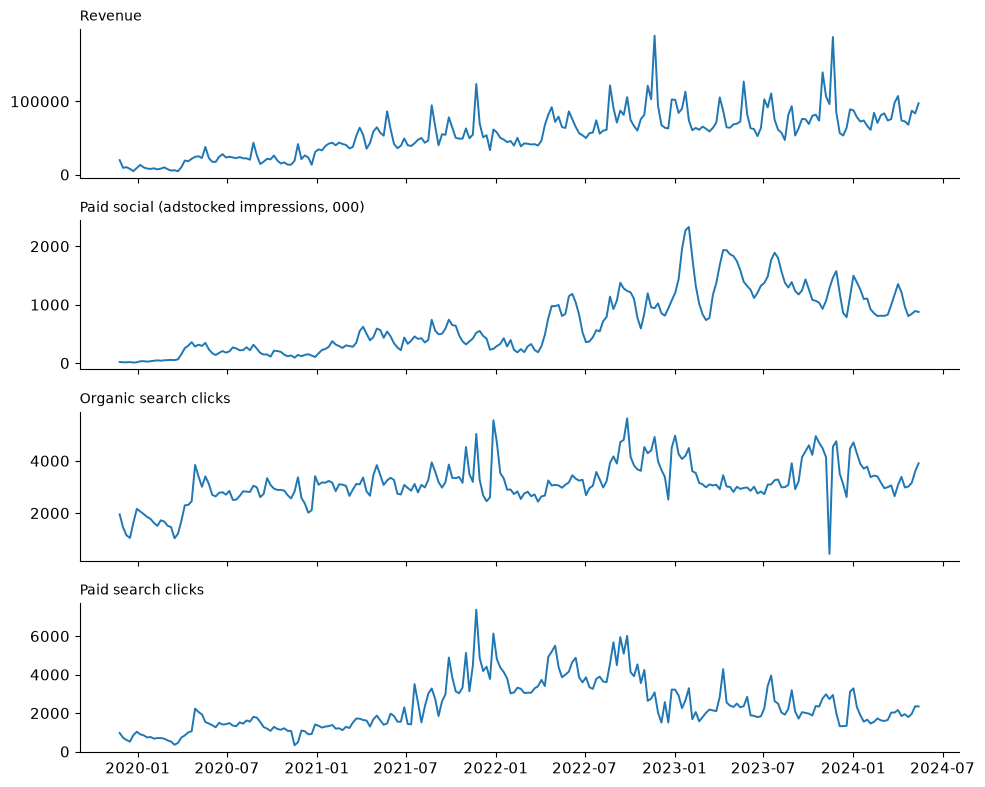

In [9]:
# Look at the series before modelling 
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
for ax, (column, label) in zip(axes, [("revenue", "Revenue"), ("social", "Paid social (adstocked impressions, 000)"),
                                      ("demand", "Organic search clicks"), ("search", "Paid search clicks")]):
    ax.plot(w.index, w[column], lw=1.4)
    ax.set_title(label, loc="left", fontsize=10)
fig.tight_layout()
plt.show()

In [ ]:
# How strongly do the four series move together: 
# Be careful with this metric in case you data has a lot of zeroes, or has a strong lagged behaviour 
w[["revenue", "social", "demand", "search"]].corr().round(2)

,revenue,social,demand,search
revenue,1.00,0.74,0.67,0.54
social,0.74,1.00,0.50,0.34
demand,0.67,0.50,1.00,0.55
search,0.54,0.34,0.55,1.00


## 5. Step 1: the usual single-stage model

One regression: revenue on both channels and the controls. A channel's return is its coefficient times its volume, divided by its cost.

In [13]:
def fit(y, X):
    """Linear regression; standard errors allow for week-to-week correlation."""
    return sm.OLS(y, sm.add_constant(X)).fit(cov_type="HAC", cov_kwds={"maxlags": 4})


per_search = w["search"].sum() / w["search_cost"].sum()   # clicks per 1 of spend
per_social = w["social"].sum() / w["social_cost"].sum()   # impressions per 1 of spend

single = fit(w["revenue"], w[["social", "search"] + CONTROLS])
print(f"Search {single.params['search'] * per_search:.2f}, social {single.params['social'] * per_social:.2f}")

Search 9.04, social 1.04


In [14]:
# Coefficients and t-values, if you want the detail
pd.DataFrame({"coefficient": single.params, "t": single.tvalues}).round(2)

,coefficient,t
const,10600.47,3.40
social,7.69,1.74
search,8.79,8.17
other_paid,7.81,3.49
trend,66.89,1.66
sin,-490.35,-0.25
cos,-2013.13,-1.13


In [ ]:
## Note: This notebook deliberately does not go deeper into exploring the stability of these coefficients.
## The only aim to this demonstration is to show that not controlling for demand leads to an inflated ROAS for search
# and deflated for social/ display (whichever is your upper funnel channel)

## 6. Step 2: add search demand as a control

The model now compares weeks with the same level of searching, so paid search only gets credit for revenue that moves with its clicks when demand is held still.

In [15]:
controlled = fit(w["revenue"], w[["social", "search", "demand"] + CONTROLS])
print(f"Search {controlled.params['search'] * per_search:.2f}, social {controlled.params['social'] * per_social:.2f}")

fall = controlled.params["search"] / single.params["search"] - 1
print(f"Search return changes by {fall:+.0%}")

Search 6.89, social 0.77
Search return changes by -24%


## 7. Step 3: give paid social its credit back :D
 
Two small regressions ask how much organic and paid search activity follows paid social. Their results are multiplied through the Step 2 model and added to social's direct effect.

In [18]:
stage1 = fit(w["demand"], w[["social"] + CONTROLS])          # organic searches that follow social
stage1_search = fit(w["search"], w[["social"] + CONTROLS])   # paid search clicks that follow social

direct = controlled.params["social"] * per_social
via_organic = stage1.params["social"] * controlled.params["demand"] * per_social
via_paid = stage1_search.params["social"] * controlled.params["search"] * per_social
total = direct + via_organic + via_paid

print(f"Social: direct {direct:.2f} + via organic search {via_organic:.2f} + via paid search {via_paid:.2f} = {total:.2f}")
print(f"Stage 1 t-value: {stage1.tvalues['social']:.1f}")

Social: direct 0.77 + via organic search 0.44 + via paid search 0.57 = 1.78
Stage 1 t-value: 2.0


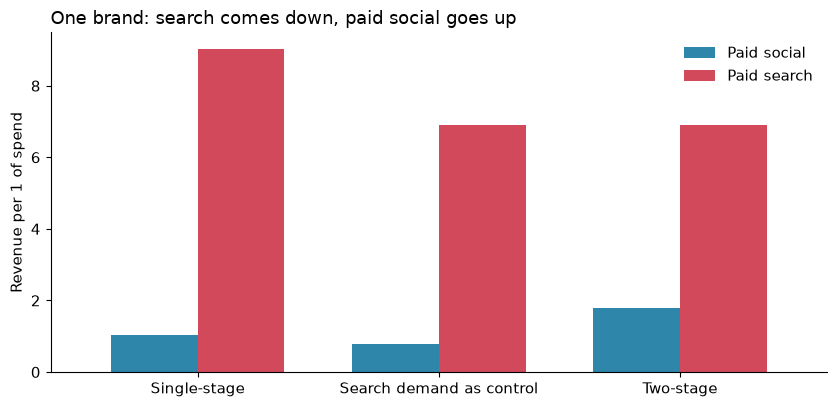

,Paid search,Paid social
Single-stage,9.04,1.04
Search demand as control,6.89,0.77
Two-stage,6.89,1.78


In [19]:
# The three models side by side
results = pd.DataFrame({
    "Paid search": [single.params["search"] * per_search, controlled.params["search"] * per_search,
                    controlled.params["search"] * per_search],
    "Paid social": [single.params["social"] * per_social, direct, total],
}, index=["Single-stage", "Search demand as control", "Two-stage"]).round(2)

ax = results[["Paid social", "Paid search"]].plot.bar(color=["#2e86ab", "#d1495b"], figsize=(8.5, 4.2), rot=0, width=0.72)
ax.set_ylabel("Revenue per 1 of spend")
ax.set_title("One brand: search comes down, paid social goes up", loc="left")
ax.legend(frameon=False)
pathlib.Path("charts").mkdir(exist_ok=True)
plt.tight_layout()
plt.savefig("charts/brand_three_models.png", dpi=160)
plt.show()
results